# 방범용 CCTV 위치와 인구 데이터분석
- https://data.busan.go.kr/
- 부산광역시_방범용 CCTV 정보 검색 -> csv 파일 다운로드

- https://jumin.mois.go.kr/
- CCTV와 같은 날짜의 인구를 검색 -> csv 파일 다운로드

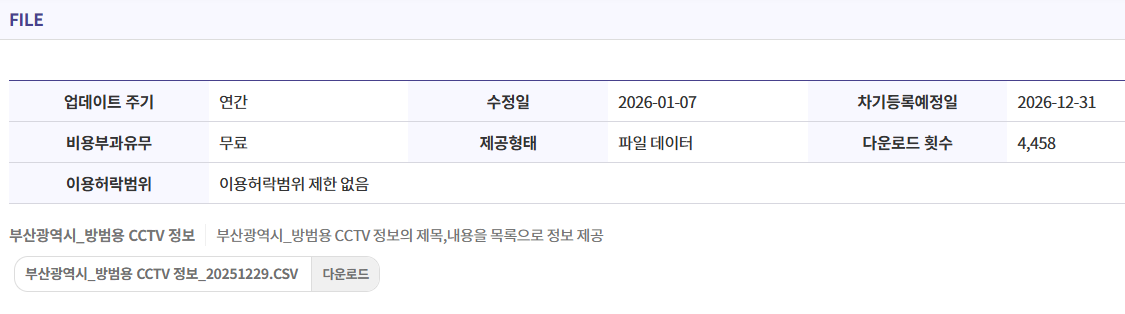
<hr/>

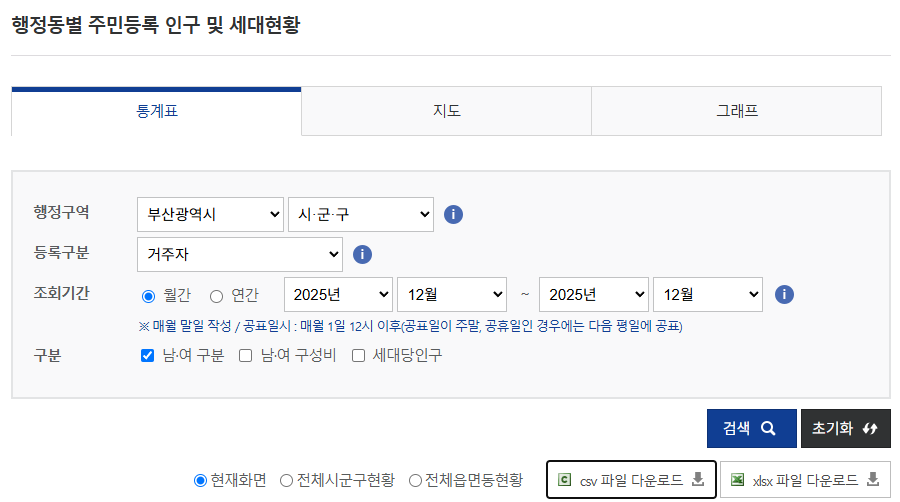

In [1]:
from hdfs import InsecureClient
import pandas as pd
import matplotlib.pyplot as plt

Text(0.2, 0.4, '한글')

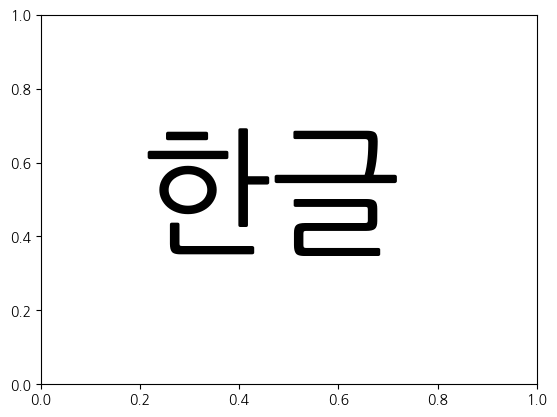

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
plt.rc('font', family='NanumGothic')
plt.text(0.2,0.4, '한글', size=100)

In [3]:
client_hdfs = InsecureClient('http://namenode:9870',user='hadoop')
path_cctv = "/dataset/부산광역시방범용CCTV정보202512.csv"
path_jumin = "/dataset/주민등록인구및세대현황202512.csv"

with client_hdfs.read(path_cctv, encoding='cp949') as reader:
    cctv = pd.read_csv(reader)
with client_hdfs.read(path_jumin, encoding='cp949') as reader:
    jumin = pd.read_csv(reader, thousands=",") # thousands="," 콤마제거
# cctv
# jumin

In [4]:
cctv.rename(columns={'구군':'local'}, inplace=True )
cctv_count = cctv['local'].value_counts()
cctv_count
cctv['local'].describe()

count     21060
unique       16
top          남구
freq       2032
Name: local, dtype: object

In [5]:
jumin_data = jumin.loc[1:,'행정구역':'2025년12월_거주자 인구수']
jumin_data.columns = ['local', 'value']
jumin_data['local'] = jumin_data['local'].str.replace('부산광역시 ','')
jumin_data['local'] = [data[0] for data in jumin_data['local'].str.split(' ')]
jumin_data

,local,value
1,중구,36223
2,서구,101406
3,동구,83352
4,영도구,101104
5,부산진구,363555
6,동래구,272339
7,남구,249640
8,북구,262076
9,해운대구,370561
10,사하구,285207


In [6]:
result = pd.merge(cctv_count, jumin_data, on='local')
result = result.set_index('local')
result

,count,value
local,,
남구,2032,249640
사하구,1823,285207
북구,1714,262076
해운대구,1683,370561
강서구,1668,150008
기장군,1508,174429
부산진구,1477,363555
금정구,1284,205802
연제구,1241,211062


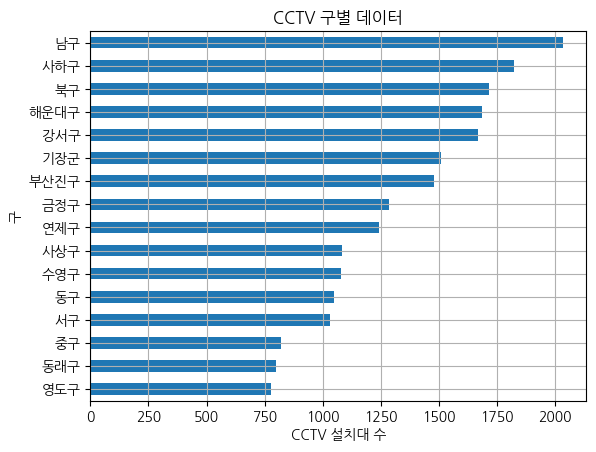

In [7]:
import matplotlib.pyplot as plt
result['count'].sort_values().plot(kind='barh',ylabel='구')
plt.title('CCTV 구별 데이터')
plt.xlabel('CCTV 설치대 수')
plt.grid()
plt.show()

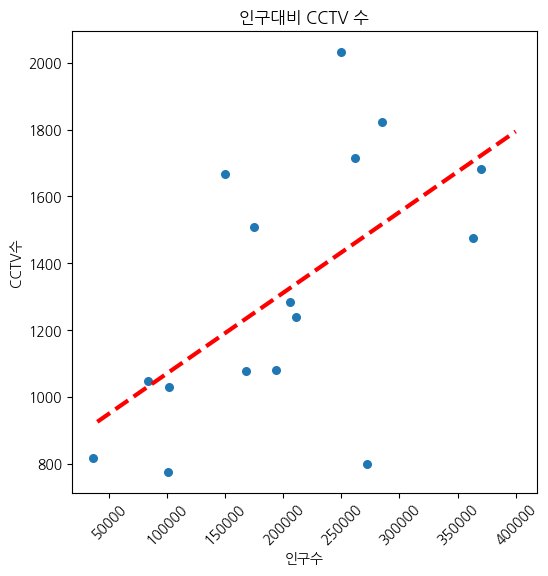

In [8]:
import numpy as np
xx = result['value']
yy = result['count']

plt.figure(figsize=(6,6))

plt.scatter(xx, yy, s=30)

# 회귀선 1
pf = np.polyfit(xx, yy, 1)
pf1d = np.poly1d(pf)
fx = np.linspace(40000,400000,10)
plt.plot(fx, pf1d(fx), c='r', lw=3, ls='--')

plt.title('인구대비 CCTV 수')
plt.xlabel('인구수')
plt.xticks(rotation=45)
plt.ylabel('CCTV수')
plt.show()

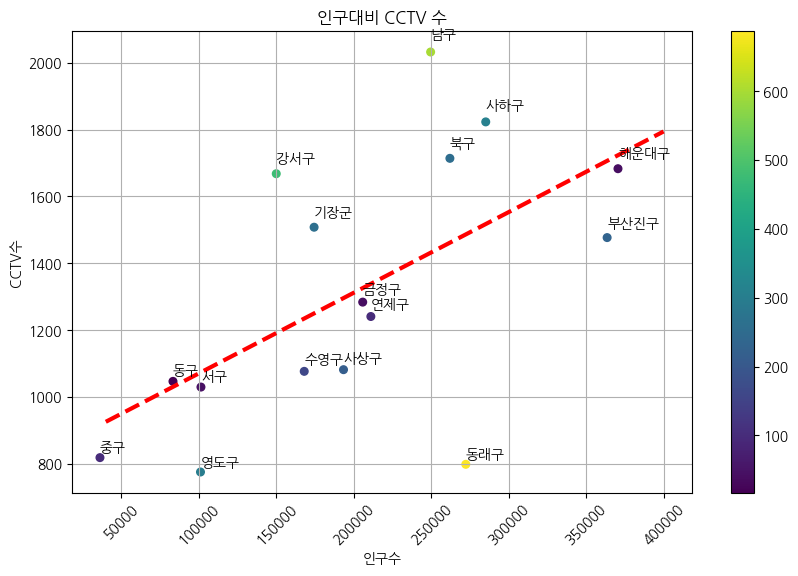

In [18]:
from sklearn.linear_model import LinearRegression
xx = result['value']
yy = result['count']

plt.figure(figsize=(10,6))

# 회귀선 2
rx = xx.values.reshape(-1,1) # 2d로 변환 함수
ry = yy.values
model = LinearRegression()
model.fit(rx, ry)
fx = np.linspace(40000,400000,10).reshape(-1,1)
plt.plot(fx, model.predict(fx), c='r', lw=3, ls='--')

# 색을 부여 (편차)
result['dev'] = np.abs(result['count'] - model.predict(rx))
plt.scatter(xx, yy, s=30, c=result['dev'])

# # 점마다 각 구의 이름을 부여
gu = list(result.index)
for gg in gu:
    plt.text(result['value'].loc[gg], result['count'].loc[gg] *1.02 , gg)

plt.title('인구대비 CCTV 수')
plt.xlabel('인구수')
plt.xticks(rotation=45)
plt.ylabel('CCTV수')
plt.colorbar()
plt.grid()
plt.show()
